# 2. Analytics in R

In this section we will use R to plot the new tables that we created in the previous section

In [ ]:
%load_ext rpy2.ipython

In [ ]:
%%R
# Installing and importing all important plotting libraries in R

install.packages(c("sqldf", "ggridges", "ggplot", "scales", "RColorBrewer"))
library(sqldf)
library(ggridges)
library(ggplot2)
library(scales)
library(RColorBrewer)

# Setting a default template of all plots
theme_update(
  plot.title    = element_text(size = 12, face = "bold"),
  plot.subtitle = element_text(size = 9),
  plot.margin   = margin(10, 20, 10, 10)
)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’

trying URL 'https://cran.rstudio.com/src/contrib/gsubfn_0.7.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/proto_1.0.0.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/RSQLite_2.4.6.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/chron_2.3-62.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/sqldf_0.4-12.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/ggridges_0.5.7.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/scales_1.4.0.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/RColorBrewer_1.1-3.tar.gz'

The downloaded source packages are in
	‘/tmp/Rtmp8VeIWX/downloaded_packages’
Loading required package: gsubfn
Loading required package: proto
Loading required package: RSQLite
Posit Community (formerly RStudio Community) is a great place to get
help: https://forum.posit.co/c/ti

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%%R
# Get all new tables created in SQL_R to analyze trends and find insights

hub_performance <- read.csv('/content/drive/MyDrive/DBA/SQL_Files/hub_performance.csv', stringsAsFactors = FALSE, na.strings = c("", "NA", "N/A"))
route_override_analysis <- read.csv('/content/drive/MyDrive/DBA/SQL_Files/route_override_analysis.csv', stringsAsFactors = FALSE, na.strings = c("", "NA", "N/A"))
driver_zone_performance <- read.csv('/content/drive/MyDrive/DBA/SQL_Files/driver_zone_performance.csv', stringsAsFactors = FALSE, na.strings = c("", "NA", "N/A"))
customer_failure_view <- read.csv('/content/drive/MyDrive/DBA/SQL_Files/customer_failure_view.csv', stringsAsFactors = FALSE, na.strings = c("", "NA", "N/A"))
complaint_delivery_link <- read.csv('/content/drive/MyDrive/DBA/SQL_Files/complaint_delivery_link.csv', stringsAsFactors = FALSE, na.strings = c("", "NA", "N/A"))
high_risk_customers <- read.csv('/content/drive/MyDrive/DBA/SQL_Files/high_risk_customers.csv', stringsAsFactors = FALSE, na.strings = c("", "NA", "N/A"))
service_profitability <- read.csv('/content/drive/MyDrive/DBA/SQL_Files/service_profitability.csv', stringsAsFactors = FALSE, na.strings = c("", "NA", "N/A"))
zone_cost_analysis <- read.csv('/content/drive/MyDrive/DBA/SQL_Files/zone_cost_analysis.csv', stringsAsFactors = FALSE, na.strings = c("", "NA", "N/A"))
compensation_by_complaint <- read.csv('/content/drive/MyDrive/DBA/SQL_Files/compensation_by_complaint.csv', stringsAsFactors = FALSE, na.strings = c("", "NA", "N/A"))
app_event_complexity <- read.csv('/content/drive/MyDrive/DBA/SQL_Files/app_event_complexity.csv', stringsAsFactors = FALSE, na.strings = c("", "NA", "N/A"))
incident_vehicle_profile <- read.csv('/content/drive/MyDrive/DBA/SQL_Files/incident_vehicle_profile.csv', stringsAsFactors = FALSE, na.strings = c("", "NA", "N/A"))
fragmentation_evidence <- read.csv('/content/drive/MyDrive/DBA/SQL_Files/fragmentation_evidence.csv', stringsAsFactors = FALSE, na.strings = c("", "NA", "N/A"))


# TABLE 1: hub_performance
## Statistical Method: Correlation Test
## Graphs: 2
### STATISTICAL TEST 1 — Pearson Correlation: Capacity Score vs Failure Rate

Purpose: Tests whether hubs with higher capacity scores actually perform
better (lower failure rates), or whether capacity is unrelated to outcomes.
A negative correlation would mean higher capacity = fewer failures (expected).
No correlation would mean capacity alone cannot explain hub underperformance.


In [ ]:
%%R

cor_test_result <- cor.test(
  hub_performance$capacity_score,
  hub_performance$failure_rate_pct,
  method = "pearson"
)

cat("\n--- STATISTICAL TEST 1: Pearson Correlation ---\n")
cat("Capacity Score vs Failure Rate\n")
print(cor_test_result)

# Interpretation helper
cat("\nCorrelation coefficient (r):", round(cor_test_result$estimate, 4), "\n")
cat("p-value                    :", round(cor_test_result$p.value, 4), "\n")
cat("Interpretation: If p > 0.05, no significant linear relationship exists\n")
cat("between hub capacity and failure rate — meaning capacity investment alone\n")
cat("is not sufficient to explain or fix hub underperformance.\n")


--- STATISTICAL TEST 1: Pearson Correlation ---
Capacity Score vs Failure Rate

	Pearson's product-moment correlation

data:  hub_performance$capacity_score and hub_performance$failure_rate_pct
t = 0.04423, df = 6, p-value = 0.9662
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.6954669  0.7136476
sample estimates:
       cor 
0.01805372 


Correlation coefficient (r): 0.0181 
p-value                    : 0.9662 
Interpretation: If p > 0.05, no significant linear relationship exists
between hub capacity and failure rate — meaning capacity investment alone
is not sufficient to explain or fix hub underperformance.


Saving 6.67 x 6.67 in image


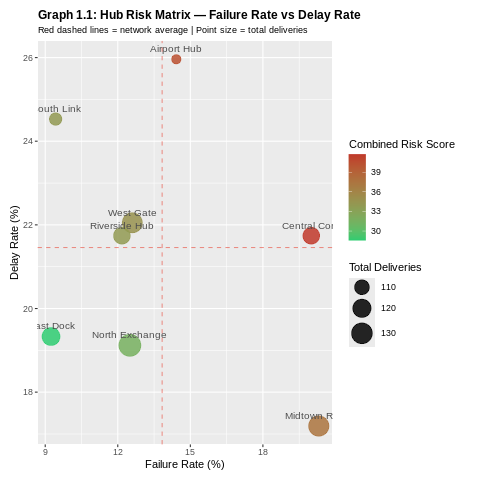

In [ ]:
%%R

# GRAPH 1.1 — Hub Failure vs Delay Rate (Scatter with labels)
# Purpose: Plots every hub on two performance dimensions simultaneously —
# failure rate on x and delay rate on y. Hubs in the top-right quadrant
# are failing on BOTH dimensions and need urgent intervention.

# Add a combined risk score for colour gradient
hub_performance$combined_risk <- hub_performance$failure_rate_pct + hub_performance$delay_rate_pct

plot1 <- ggplot(hub_performance,
       aes(x = failure_rate_pct,
           y = delay_rate_pct,
           color = combined_risk,
           size  = total_deliveries)) +
  geom_point(alpha = 0.85) +
  geom_text(aes(label = hub_name),
            vjust = -1.2, size = 3.5, color = "grey30") +
  # Reference lines at network averages
  geom_vline(xintercept = mean(hub_performance$failure_rate_pct),
             linetype = "dashed", color = "#e74c3c", alpha = 0.6) +
  geom_hline(yintercept = mean(hub_performance$delay_rate_pct),
             linetype = "dashed", color = "#e74c3c", alpha = 0.6) +
  scale_color_gradient(low = "#2ecc71", high = "#c0392b") +
  scale_size_continuous(range = c(4, 10)) +
  labs(
    title    = "Graph 1.1: Hub Risk Matrix — Failure Rate vs Delay Rate",
    subtitle = "Red dashed lines = network average | Point size = total deliveries",
    x        = "Failure Rate (%)",
    y        = "Delay Rate (%)",
    color    = "Combined Risk Score",
    size     = "Total Deliveries"
  )

ggsave('/content/drive/MyDrive/DBA/R_Graphs/1.1.png')
print(plot1)

Saving 6.67 x 6.67 in image
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


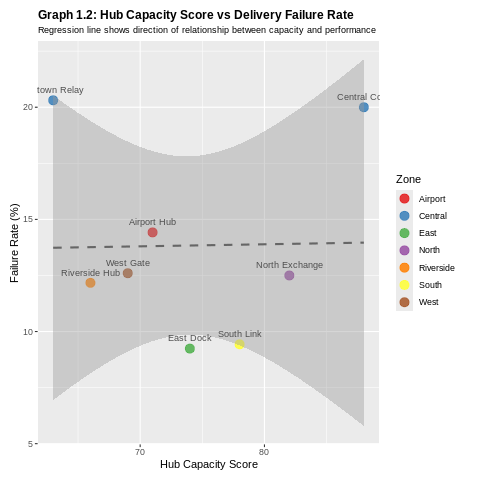

In [ ]:
# GRAPH 1.2 — Capacity Score vs Failure Rate (Scatter with regression line)
# Purpose: Visualises the correlation test result above. If the regression
# line is flat or positive, it confirms that higher capacity does not
# protect against failures — a key finding against the assumption that
# expanding hub capacity will solve the performance problem.
%%R

plot12 <- ggplot(hub_performance,
       aes(x = capacity_score,
           y = failure_rate_pct,
           color = zone)) +
  geom_point(size = 4, alpha = 0.85) +
  geom_smooth(method = "lm", se = TRUE,
              color = "grey40", linetype = "dashed", linewidth = 1) +
  geom_text(aes(label = hub_name),
            vjust = -1.2, size = 3.2, color = "grey30") +
  scale_color_brewer(palette = "Set1") +
  labs(
    title    = "Graph 1.2: Hub Capacity Score vs Delivery Failure Rate",
    subtitle = "Regression line shows direction of relationship between capacity and performance",
    x        = "Hub Capacity Score",
    y        = "Failure Rate (%)",
    color    = "Zone"
  )

 ggsave('/content/drive/MyDrive/DBA/R_Graphs/1.2.png')
 print(plot12)

# TABLE 2: customer_failure_view
## Graphs: 2
## GRAPH 2.1 — Failed vs Delayed Deliveries per Customer Segment (Stacked Bar)

Purpose: Segments customers by how many failures they have experienced and shows the breakdown of failed vs delayed deliveries within each segment. Highlights the compounding burden on repeat-failure customers.

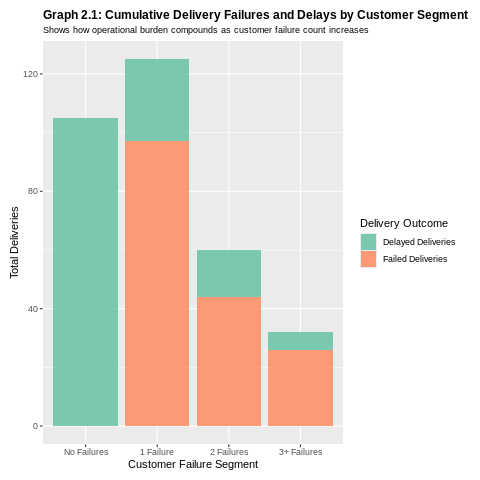

In [ ]:
%%R
# GRAPH 2.1 — Failed vs Delayed Deliveries per Customer Segment (Stacked Bar)
# Purpose: Segments customers by how many failures they have experienced
# and shows the breakdown of failed vs delayed deliveries within each segment.
# Highlights the compounding burden on repeat-failure customers.

# Create failure segments
customer_failure_view$failure_segment <- cut(
  customer_failure_view$failed_deliveries,
  breaks = c(-Inf, 0, 1, 2, Inf),
  labels = c("No Failures", "1 Failure", "2 Failures", "3+ Failures")
)

# Aggregate for plotting
segment_summary <- aggregate(
  cbind(failed_deliveries, delayed_deliveries, total_complaints,
        total_compensation_paid) ~ failure_segment,
  data = customer_failure_view,
  FUN  = sum
)

# Reshape to long format for stacked bar
segment_long <- rbind(
  data.frame(failure_segment = segment_summary$failure_segment,
             metric = "Failed Deliveries",
             value  = segment_summary$failed_deliveries),
  data.frame(failure_segment = segment_summary$failure_segment,
             metric = "Delayed Deliveries",
             value  = segment_summary$delayed_deliveries)
)

plot2 <- ggplot(segment_long,
       aes(x = failure_segment, y = value, fill = metric)) +
  geom_col(position = "stack", alpha = 0.85) +
  scale_fill_brewer(palette = "Set2") +
  labs(
    title    = "Graph 2.1: Cumulative Delivery Failures and Delays by Customer Segment",
    subtitle = "Shows how operational burden compounds as customer failure count increases",
    x        = "Customer Failure Segment",
    y        = "Total Deliveries",
    fill     = "Delivery Outcome"
  )

ggsave('/content/drive/MyDrive/DBA/R_Graphs/2.1.png', width=10, height=10)
print(plot2)

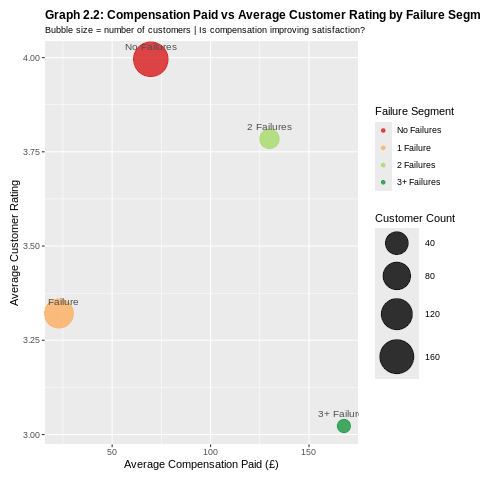

In [ ]:
# GRAPH 2.2 — Average Rating vs Total Compensation by Failure Segment (Bubble)
# Purpose: Shows the relationship between how much compensation customers
# receive and how satisfied they remain. Customers receiving high compensation
# but still rating poorly indicate money is not fixing the underlying problem.
# Bubble size represents number of customers in each segment.
%%R

# Aggregate average rating and total compensation per segment
bubble_data <- aggregate(
  cbind(avg_rating, total_compensation_paid) ~ failure_segment,
  data = customer_failure_view,
  FUN  = mean
)

# Add customer count per segment
bubble_data$customer_count <- as.numeric(table(
  customer_failure_view$failure_segment))

plot22 <- ggplot(bubble_data,
       aes(x     = total_compensation_paid,
           y     = avg_rating,
           size  = customer_count,
           color = failure_segment)) +
  geom_point(alpha = 0.8) +
  geom_text(aes(label = failure_segment),
            vjust = -1.5, size = 3.5, color = "grey30") +
  scale_size_continuous(range = c(6, 16)) +
  scale_color_brewer(palette = "RdYlGn") +
  labs(
    title    = "Graph 2.2: Compensation Paid vs Average Customer Rating by Failure Segment",
    subtitle = "Bubble size = number of customers | Is compensation improving satisfaction?",
    x        = "Average Compensation Paid (£)",
    y        = "Average Customer Rating",
    color    = "Failure Segment",
    size     = "Customer Count"
  ) +
  theme(legend.position = "right")

ggsave('/content/drive/MyDrive/DBA/R_Graphs/2.2.png', width=13, height=10)
print(plot22)

# TABLE 3: complaint_delivery_link
## Graphs: 2
## STATISTICAL TEST 2 — Chi-Square Test: Complaint Severity vs Delivery Status

Purpose: Tests whether complaint severity and delivery status are statistically independent. If they are NOT independent (p < 0.05), it means severity labels are influenced by delivery outcome — the systems are connected in classification. If they ARE independent (p > 0.05), severity is being assigned without reference to the delivery record, proving the two systems operate in complete isolation.

In [ ]:
%%R
# Chi-Square Test: Complaint Severity vs Delivery Status
# Purpose: Tests whether complaint severity and delivery status are statistically independent

# Build contingency table
severity_delivery_table <- table(
  complaint_delivery_link$severity,
  complaint_delivery_link$delivery_status
)

chi_test_result <- chisq.test(severity_delivery_table)

cat("\n--- STATISTICAL TEST 2: Chi-Square Test ---\n")
cat("Complaint Severity vs Delivery Status\n")
print(chi_test_result)
print(severity_delivery_table)

cat("\nInterpretation: If p > 0.05, severity and delivery status are statistically\n")
cat("independent — complaint severity is assigned without reference to\n")
cat("the actual delivery outcome, confirming system disconnection.\n")


--- STATISTICAL TEST 2: Chi-Square Test ---
Complaint Severity vs Delivery Status

	Pearson's Chi-squared test

data:  severity_delivery_table
X-squared = 4.1077, df = 2, p-value = 0.1282

        
         Delayed Failed OnTime
  High        12     13     28
  Medium      30     17     86

Interpretation: If p > 0.05, severity and delivery status are statistically
independent — complaint severity is assigned without reference to
the actual delivery outcome, confirming system disconnection.


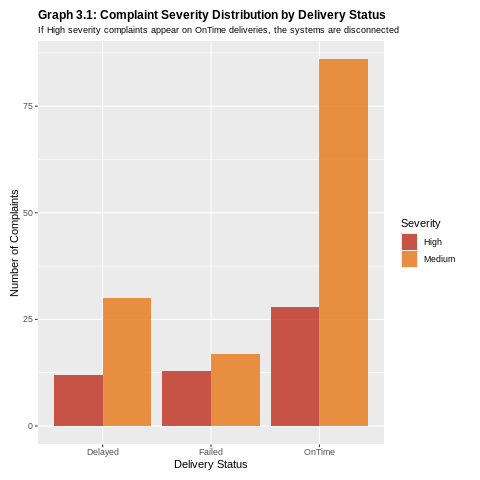

In [ ]:
# GRAPH 3.1 — Complaint Severity Distribution by Delivery Status (Grouped Bar)
# Purpose: Visualises the chi-square test result. Shows whether High severity
# complaints concentrate around Failed deliveries (expected) or are spread
# equally across OnTime, Delayed and Failed (proving disconnection).
%%R

# Aggregate counts
severity_counts <- as.data.frame(severity_delivery_table)
colnames(severity_counts) <- c("severity", "delivery_status", "count")

plot31 <- ggplot(severity_counts,
       aes(x = delivery_status, y = count, fill = severity)) +
  geom_col(position = "dodge", alpha = 0.85) +
  scale_fill_manual(values = c("High"   = "#c0392b",
                                "Medium" = "#e67e22",
                                "Low"    = "#27ae60")) +
  labs(
    title    = "Graph 3.1: Complaint Severity Distribution by Delivery Status",
    subtitle = "If High severity complaints appear on OnTime deliveries, the systems are disconnected",
    x        = "Delivery Status",
    y        = "Number of Complaints",
    fill     = "Severity"
  )

ggsave('/content/drive/MyDrive/DBA/R_Graphs/3.1.png', width=13, height=10)
print(plot31)

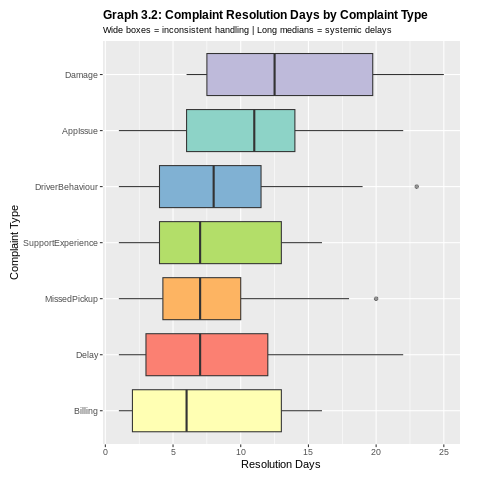

In [ ]:
# GRAPH 3.2 — Resolution Days by Complaint Type (Boxplot
# Purpose: Shows the spread of resolution times across complaint types.
# Wide IQR boxes indicate inconsistent handling. Types with long median
# resolution times AND wide spreads represent the most chaotic complaint
# management processes.
%%R

plot32 <- ggplot(complaint_delivery_link,
       aes(x    = reorder(complaint_type, resolution_days, FUN = median),
           y    = resolution_days,
           fill = complaint_type)) +
  geom_boxplot(outlier.alpha = 0.5, outlier.size = 1.5) +
  coord_flip() +
  scale_fill_brewer(palette = "Set3") +
  labs(
    title    = "Graph 3.2: Complaint Resolution Days by Complaint Type",
    subtitle = "Wide boxes = inconsistent handling | Long medians = systemic delays",
    x        = "Complaint Type",
    y        = "Resolution Days",
    fill     = "Complaint Type"
  ) +
  theme(legend.position = "none")

ggsave('/content/drive/MyDrive/DBA/R_Graphs/3.2.png', width=13, height=10)
print(plot32)

# TABLE 4: service_profitability
## Statistical Method: Linear Regression
## Graphs: 2
### STATISTICAL TEST 3 — Linear Regression: Delivery Cost vs Gross Margin

Purpose: Tests whether higher delivery costs predict higher gross margins
across service types and priority levels. A positive coefficient would mean
spending more generates more margin. A weak or negative R-squared would
confirm that cost and margin are not linked — operational efficiency,
not spending, drives profitability.

In [ ]:
%%R
#Linear Regression: Delivery Cost vs Gross Margin
#
# Purpose: Tests whether higher delivery costs predict higher gross margins
# across service types and priority levels.

lm_model <- lm(avg_gross_margin ~ avg_delivery_cost + service_type,
               data = service_profitability)

cat("\n--- STATISTICAL TEST 3: Linear Regression ---\n")
cat("Delivery Cost + Service Type vs Gross Margin\n")
print(summary(lm_model))

cat("\nInterpretation: R-squared shows how much of margin variance is explained\n")
cat("by delivery cost and service type. Low R-squared means other factors\n")
cat("(route efficiency, failure rate, driver allocation) are the real\n")
cat("drivers of profitability — not the cost of the delivery itself.\n")


--- STATISTICAL TEST 3: Linear Regression ---
Delivery Cost + Service Type vs Gross Margin

Call:
lm(formula = avg_gross_margin ~ avg_delivery_cost + service_type, 
    data = service_profitability)

Residuals:
   Min     1Q Median     3Q    Max 
-8.279 -3.600 -1.577  4.664  9.983 

Coefficients:
                      Estimate Std. Error t value Pr(>|t|)  
(Intercept)             57.781     23.429   2.466   0.0272 *
avg_delivery_cost        2.104      1.804   1.166   0.2629  
service_typeMedical    -12.362      4.615  -2.679   0.0180 *
service_typeParcel      -8.315      4.537  -1.833   0.0882 .
service_typePassenger    3.137      4.718   0.665   0.5169  
service_typeRetail     -12.362      4.538  -2.724   0.0165 *
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 6.397 on 14 degrees of freedom
Multiple R-squared:  0.5986,	Adjusted R-squared:  0.4553 
F-statistic: 4.176 on 5 and 14 DF,  p-value: 0.01564


Interpretation: R-squared shows how m

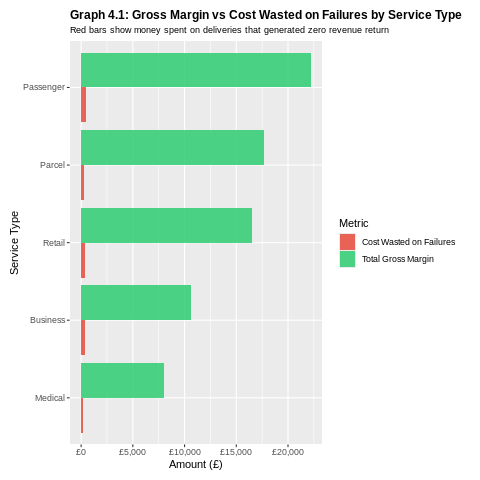

In [ ]:
# GRAPH 4.1 — Gross Margin vs Cost on Failed Deliveries by Service Type (Bar)
# Purpose: Directly compares what each service type earns (gross margin)
# against what it wastes on failed deliveries (cost with no return).
%%R

# Aggregate to service type level
service_summary <- aggregate(
  cbind(total_gross_margin, cost_on_failed_deliveries,
        total_revenue, total_cost) ~ service_type,
  data = service_profitability,
  FUN  = sum
)

# Reshape for grouped bar
service_long <- rbind(
  data.frame(service_type = service_summary$service_type,
             metric = "Total Gross Margin",
             value  = service_summary$total_gross_margin),
  data.frame(service_type = service_summary$service_type,
             metric = "Cost Wasted on Failures",
             value  = service_summary$cost_on_failed_deliveries)
)

plot41 <- ggplot(service_long,
       aes(x = reorder(service_type, value),
           y = value,
           fill = metric)) +
  geom_col(position = "dodge", alpha = 0.85) +
  coord_flip() +
  scale_fill_manual(values = c("Total Gross Margin"      = "#2ecc71",
                                "Cost Wasted on Failures" = "#e74c3c")) +
  scale_y_continuous(labels = dollar_format(prefix = "£")) +
  labs(
    title    = "Graph 4.1: Gross Margin vs Cost Wasted on Failures by Service Type",
    subtitle = "Red bars show money spent on deliveries that generated zero revenue return",
    x        = "Service Type",
    y        = "Amount (£)",
    fill     = "Metric"
  )

ggsave('/content/drive/MyDrive/DBA/R_Graphs/4.1.png', width=13, height=10)
print(plot41)

Saving 6.67 x 6.67 in image


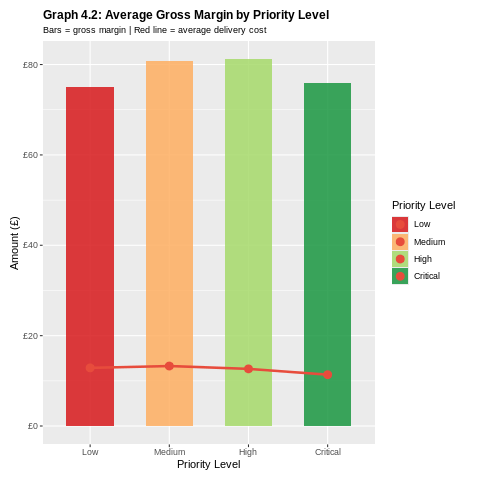

In [ ]:
# GRAPH 4.2 — Average Gross Margin by Priority Level (Bar with error context)
# Purpose: Shows whether higher priority levels justify their resource cost
# with proportionally better margins. Flat or declining margins across
# priority levels would confirm the finance director's concern that the
# priority system is not financially calibrated.
%%R

priority_summary <- aggregate(
  cbind(avg_gross_margin, avg_delivery_cost,
        avg_order_value) ~ priority_level,
  data = service_profitability,
  FUN  = mean
)

# Set logical factor order
priority_summary$priority_level <- factor(
  priority_summary$priority_level,
  levels = c("Low", "Medium", "High", "Critical")
)

plot42 <- ggplot(priority_summary,
       aes(x = priority_level,
           y = avg_gross_margin,
           fill = priority_level)) +
  geom_col(alpha = 0.85, width = 0.6) +
  geom_line(aes(y = avg_delivery_cost, group = 1),
            color = "#e74c3c", linewidth = 1.2) +
  geom_point(aes(y = avg_delivery_cost),
             color = "#e74c3c", size = 3.5) +
  scale_fill_brewer(palette = "RdYlGn") +
  scale_y_continuous(labels = dollar_format(prefix = "£")) +
  labs(
    title    = "Graph 4.2: Average Gross Margin by Priority Level",
    subtitle = "Bars = gross margin | Red line = average delivery cost",
    x        = "Priority Level",
    y        = "Amount (£)",
    fill     = "Priority Level"
  )

ggsave('/content/drive/MyDrive/DBA/R_Graphs/4.2.png')
print(plot42)

# TABLE 5: zone_cost_analysis
## Graphs: 2
## GRAPH 5.1 — Net Margin After Compensation by Zone (Waterfall-style Bar)

Purpose: Ranks zones by their true financial contribution after compensation payouts are deducted. Colour distinguishes zones above and below the network average net margin, making the underperforming zones immediately visible to the finance director.

Saving 6.67 x 6.67 in image


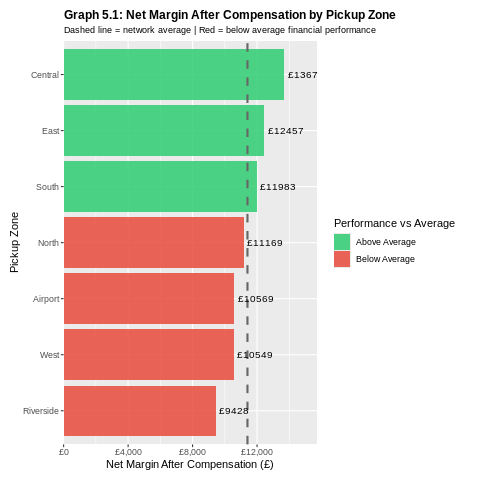

In [ ]:
%%R
# GRAPH 5.1 — Net Margin After Compensation by Zone (Waterfall-style Bar)
# Purpose: Ranks zones by their true financial contribution after compensation
# payouts are deducted.

# Add above/below average flag
zone_cost_analysis$margin_flag <- ifelse(
  zone_cost_analysis$net_margin_after_compensation >=
    mean(zone_cost_analysis$net_margin_after_compensation),
  "Above Average", "Below Average"
)

plot51 <- ggplot(zone_cost_analysis,
       aes(x    = reorder(pickup_zone, net_margin_after_compensation),
           y    = net_margin_after_compensation,
           fill = margin_flag)) +
  geom_col(alpha = 0.85) +
  geom_hline(yintercept = mean(zone_cost_analysis$net_margin_after_compensation),
             linetype = "dashed", color = "grey40", linewidth = 1) +
  geom_text(aes(label = paste0("£", round(net_margin_after_compensation, 0))),
            hjust = -0.1, size = 3.5) +
  coord_flip() +
  scale_fill_manual(values = c("Above Average" = "#2ecc71",
                                "Below Average" = "#e74c3c")) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.15)),
                     labels = dollar_format(prefix = "£")) +
  labs(
    title    = "Graph 5.1: Net Margin After Compensation by Pickup Zone",
    subtitle = "Dashed line = network average | Red = below average financial performance",
    x        = "Pickup Zone",
    y        = "Net Margin After Compensation (£)",
    fill     = "Performance vs Average"
  )

ggsave('/content/drive/MyDrive/DBA/R_Graphs/5.1.png')
print(plot51)

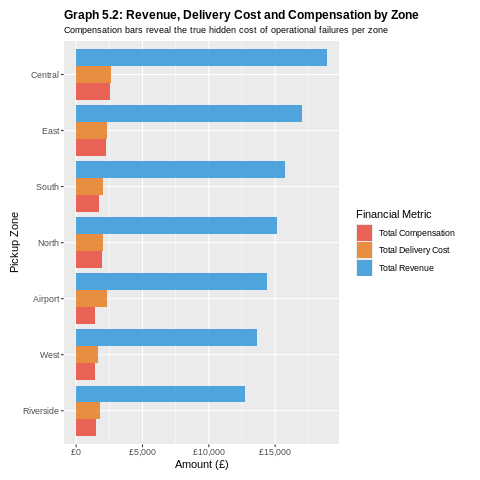

In [ ]:
# GRAPH 5.2 — Revenue, Cost, Compensation Triangle by Zone (Grouped Bar)
# Purpose: Shows all three financial components side by side for each zone —
# total revenue, total delivery cost, and total compensation paid.
%%R

# Reshape to long format
zone_long <- rbind(
  data.frame(pickup_zone = zone_cost_analysis$pickup_zone,
             metric = "Total Revenue",
             value  = zone_cost_analysis$total_revenue),
  data.frame(pickup_zone = zone_cost_analysis$pickup_zone,
             metric = "Total Delivery Cost",
             value  = zone_cost_analysis$total_delivery_cost),
  data.frame(pickup_zone = zone_cost_analysis$pickup_zone,
             metric = "Total Compensation",
             value  = zone_cost_analysis$total_compensation)
)

plot52 <- ggplot(zone_long,
       aes(x    = reorder(pickup_zone, value),
           y    = value,
           fill = metric)) +
  geom_col(position = "dodge", alpha = 0.85) +
  coord_flip() +
  scale_fill_manual(values = c("Total Revenue"       = "#3498db",
                                "Total Delivery Cost"  = "#e67e22",
                                "Total Compensation"   = "#e74c3c")) +
  scale_y_continuous(labels = dollar_format(prefix = "£")) +
  labs(
    title    = "Graph 5.2: Revenue, Delivery Cost and Compensation by Zone",
    subtitle = "Compensation bars reveal the true hidden cost of operational failures per zone",
    x        = "Pickup Zone",
    y        = "Amount (£)",
    fill     = "Financial Metric"
  )

ggsave('/content/drive/MyDrive/DBA/R_Graphs/5.2.png', width=13, height=10)
print(plot52)

# TABLE 6: incident_vehicle_profile
## Statistical Method: ANOVA
## Graphs: 2
### STATISTICAL TEST 4 — One-Way ANOVA: Resolution Hours Across Vehicle Types

Purpose: Tests whether average incident resolution hours differ significantly across vehicle types. If p < 0.05, vehicle type has a statistically significant effect on how quickly incidents are resolved — meaning some vehicle types are being systematically deprioritised in the maintenance response process.

In [ ]:
%%R

anova_model <- aov(avg_resolution_hours ~ vehicle_type,
                   data = incident_vehicle_profile)

cat("\n--- STATISTICAL TEST 2: One-Way ANOVA ---\n")
cat("Incident Resolution Hours across Vehicle Types\n")
summary(anova_model)

# Post-hoc Tukey test to identify which pairs differ
tukey_result <- TukeyHSD(anova_model)
cat("\n--- Post-Hoc Tukey HSD Test ---\n")
print(tukey_result)

cat("\nInterpretation: Tukey HSD shows which specific vehicle type pairs have\n")
cat("significantly different resolution times. Significant pairs (p < 0.05)\n")
cat("indicate unequal maintenance response prioritisation across the fleet.\n")


--- STATISTICAL TEST 2: One-Way ANOVA ---
Incident Resolution Hours across Vehicle Types

--- Post-Hoc Tukey HSD Test ---
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = avg_resolution_hours ~ vehicle_type, data = incident_vehicle_profile)

$vehicle_type
                      diff       lwr      upr     p adj
Diesel-CargoVan -1.7955409 -5.708100 2.117018 0.6331752
EV-CargoVan     -0.6279990 -4.203847 2.947849 0.9683892
Hybrid-CargoVan -1.1986842 -5.058009 2.660640 0.8513901
EV-Diesel        1.1675419 -2.465697 4.800780 0.8380996
Hybrid-Diesel    0.5968567 -3.315702 4.509416 0.9788819
Hybrid-EV       -0.5706852 -4.146533 3.005163 0.9759533


Interpretation: Tukey HSD shows which specific vehicle type pairs have
significantly different resolution times. Significant pairs (p < 0.05)
indicate unequal maintenance response prioritisation across the fleet.


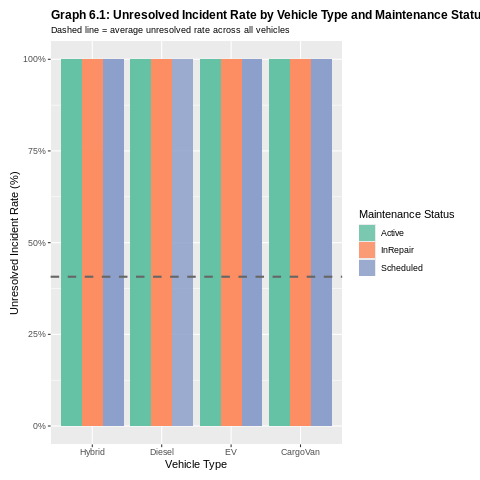

In [ ]:
# GRAPH 6.1 — Unresolved Incident Rate by Vehicle Type and Maintenance Status
# Purpose: Reveals which vehicle type and maintenance status combinations
# have the highest proportion of open and escalated incidents.
%%R

# Calculate unresolved_rate_pct from existing columns
incident_vehicle_profile$unresolved_rate_pct <- round(
  (incident_vehicle_profile$open_incidents +
   incident_vehicle_profile$escalated_incidents) * 100.0 /
   incident_vehicle_profile$total_incidents, 2
)

# Then run the plot
plot61 <- ggplot(incident_vehicle_profile,
       aes(x    = reorder(vehicle_type, unresolved_rate_pct),
           y    = unresolved_rate_pct,
           fill = maintenance_status)) +
  geom_col(position = "dodge", alpha = 0.85) +
  geom_hline(yintercept = mean(incident_vehicle_profile$unresolved_rate_pct),
             linetype = "dashed", color = "grey40", linewidth = 1) +
  scale_fill_brewer(palette = "Set2") +
  scale_y_continuous(labels = percent_format(scale = 1)) +
  labs(
    title    = "Graph 6.1: Unresolved Incident Rate by Vehicle Type and Maintenance Status",
    subtitle = "Dashed line = average unresolved rate across all vehicles",
    x        = "Vehicle Type",
    y        = "Unresolved Incident Rate (%)",
    fill     = "Maintenance Status"
  )

ggsave('/content/drive/MyDrive/DBA/R_Graphs/6.1.png', width=13, height=10)
print(plot61)

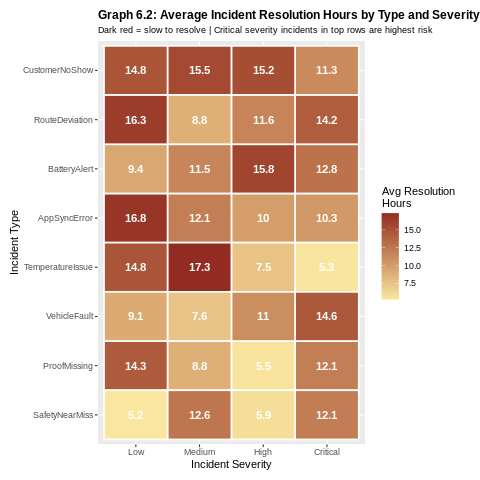

In [ ]:
# GRAPH 6.2 — Average Resolution Hours by Incident Type and Severity (Heatmap)
# Purpose: Maps every incident type against its severity level, coloured by
# average resolution hours.
%%R

# Aggregate to incident type + severity level
heatmap_data <- aggregate(
  avg_resolution_hours ~ incident_type + incident_severity,
  data = incident_vehicle_profile,
  FUN  = mean
)

# Set severity factor order
heatmap_data$incident_severity <- factor(
  heatmap_data$incident_severity,
  levels = c("Low", "Medium", "High", "Critical")
)

plot62 <- ggplot(heatmap_data,
       aes(x    = incident_severity,
           y    = reorder(incident_type, avg_resolution_hours),
           fill = avg_resolution_hours)) +
  geom_tile(color = "white", linewidth = 0.8) +
  geom_text(aes(label = round(avg_resolution_hours, 1)),
            color = "white", fontface = "bold", size = 4) +
  scale_fill_gradient(low = "#f9e79f", high = "#922b21") +
  labs(
    title    = "Graph 6.2: Average Incident Resolution Hours by Type and Severity",
    subtitle = "Dark red = slow to resolve | Critical severity incidents in top rows are highest risk",
    x        = "Incident Severity",
    y        = "Incident Type",
    fill     = "Avg Resolution\nHours"
  )

ggsave('/content/drive/MyDrive/DBA/R_Graphs/6.2.png', width=13, height=10)
print(plot62)